In [26]:
%matplotlib inline
import numpy as np
import time
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import heapq
import random

### 1. Warehouse Map

- กำหนดโครงสร้างแผนที่ตารางกริดของคลังสินค้า

In [27]:
warehouse = np.array([
    [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0]
])

### 2. Coordinate Validation

- ตรวจสอบความถูกต้องของตำแหน่งทางเข้า ทางออก และชั้นวางสินค้า

In [28]:
def validate_points(warehouse, entrance, exit_point, pickup_points):
    if warehouse[entrance] != 0: raise ValueError("Entrance must be on walkway (0)")
    if warehouse[exit_point] != 0: raise ValueError("Exit must be on walkway (0)")
    for point in pickup_points:
        if warehouse[point] != 1: raise ValueError(f"Pickup point {point} must be on shelf (1)")

### 3. Random Pickup Point Generation

- สุ่มจุดหยิบสินค้าตามจำนวนที่ต้องการพร้อมล็อกค่า seed

In [29]:
def generate_pickup_points(warehouse, n, seed=42):
    shelf_positions = list(zip(*np.where(warehouse == 1)))
    rng = np.random.default_rng(seed)
    selected_indices = rng.choice(len(shelf_positions), size=n, replace=False)
    return [shelf_positions[index] for index in selected_indices]

### 4. Warehouse Map Visualization

- ฟังก์ชันแปลงข้อมูลเป็นภาพกราฟิก

In [30]:
def plot_warehouse(warehouse, entrance, exit_point, pickup_points):
    rows, cols = warehouse.shape
    colors = ["#EAF6FF", "#4A4A4A"]
    warehouse_cmap = ListedColormap(colors)
    plt.figure(figsize=(12, 8))
    plt.imshow(warehouse, cmap=warehouse_cmap, origin="upper", interpolation="nearest")
    
    plt.scatter(entrance[1], entrance[0], color="#27AE60", s=220, edgecolors="black", zorder=3)
    plt.text(entrance[1], entrance[0], "IN", ha="center", va="center", color="white", fontweight="bold", fontsize=8, zorder=4)
    
    plt.scatter(exit_point[1], exit_point[0], color="#E74C3C", s=220, edgecolors="black", zorder=3)
    plt.text(exit_point[1], exit_point[0], "OUT", ha="center", va="center", color="white", fontweight="bold", fontsize=7, zorder=4)
    
    for index, point in enumerate(pickup_points, start=1):
        plt.scatter(point[1], point[0], color="#F1C40F", s=180, marker="s", edgecolors="black", zorder=3)
        plt.text(point[1], point[0], str(index), ha="center", va="center", fontweight="bold", color="black", zorder=4)

    plt.xticks(np.arange(-0.5, cols, 1), minor=True)
    plt.yticks(np.arange(-0.5, rows, 1), minor=True)
    plt.grid(which="minor", color="white", linestyle="-", linewidth=0.8)
    plt.title("Warehouse Map with Entrance, Exit and Pickup Points", fontsize=14, fontweight="bold")
    
    legend_elements = [
        Patch(facecolor="#EAF6FF", edgecolor="black", label="Walkway (0)"),
        Patch(facecolor="#4A4A4A", edgecolor="black", label="Shelf (1)"),
        plt.Line2D([0], [0], marker="o", color="w", label="Entrance", markerfacecolor="#27AE60", markeredgecolor="black", markersize=10),
        plt.Line2D([0], [0], marker="o", color="w", label="Exit", markerfacecolor="#E74C3C", markeredgecolor="black", markersize=10),
        plt.Line2D([0], [0], marker="s", color="w", label="Pickup Point", markerfacecolor="#F1C40F", markeredgecolor="black", markersize=10)
    ]
    
    plt.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=5)
    plt.show()

### 5. Initialize Coordinates and Display Map

- แสดงภาพแผนที่

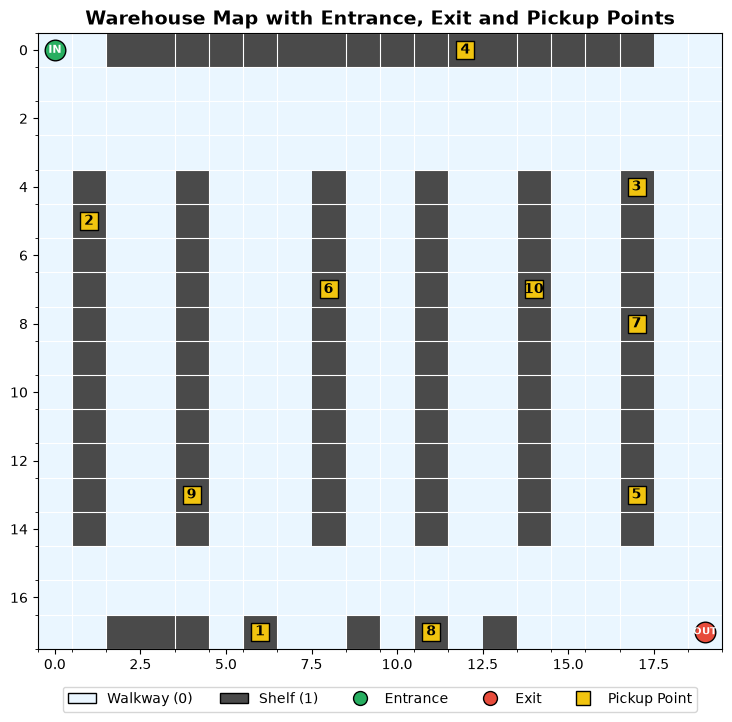

In [31]:
entrance = (0, 0)
exit_point = (17, 19)
n = 10

pickup_points = generate_pickup_points(warehouse=warehouse, n=n, seed=20)

validate_points(warehouse, entrance, exit_point, pickup_points)  
plot_warehouse(warehouse, entrance, exit_point, pickup_points) 

### 6. Print Pickup Coordinates

- แสดงพิกัดตัวเลข (Row, Column) ของจุดหยิบสินค้าทั้งหมด

In [32]:
print("Entrance:", entrance)
print("Exit:", exit_point)
for index, point in enumerate(pickup_points, start=1):
    print(f"  Pickup {index}: ({int(point[0])}, {int(point[1])})")

Entrance: (0, 0)
Exit: (17, 19)
  Pickup 1: (17, 6)
  Pickup 2: (5, 1)
  Pickup 3: (4, 17)
  Pickup 4: (0, 12)
  Pickup 5: (13, 17)
  Pickup 6: (7, 8)
  Pickup 7: (8, 17)
  Pickup 8: (17, 11)
  Pickup 9: (13, 4)
  Pickup 10: (7, 14)


## A* Search Algorithm and Distance Matrix

### 7. Stand Position Finder

- ค้นหาพิกัดจุดยืนหยิบสินค้าที่อยู่ติดกับชั้นวางสินค้า เพื่อเตรียมให้พนักงานยืนหยิบของ

In [33]:
def get_valid_stand_positions(warehouse, item_pos):
    stand_positions = []
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    for dr, dc in directions:
        nr, nc = item_pos[0] + dr, item_pos[1] + dc
        if 0 <= nr < warehouse.shape[0] and 0 <= nc < warehouse.shape[1]:
            if warehouse[nr, nc] == 0:
                stand_positions.append((nr, nc))
    return stand_positions

### 8. Shortest Path Calculation

- ใช้ A* Search คำนวณหาเส้นทางและระยะทางที่สั้นที่สุดบนแผนที่ตารางกริดระหว่างจุดเริ่มต้นและจุดหมาย

In [34]:
def a_star_search(warehouse, starts, targets):
    def heuristic(pos):
        return min(abs(pos[0] - t[0]) + abs(pos[1] - t[1]) for t in targets)
    
    pq = []
    visited = set()
    counter = 0 
    for st in starts:
        heapq.heappush(pq, (heuristic(st), 0, counter, st, [st]))
        counter += 1
        
    while pq:
        f, g, _, curr, path = heapq.heappop(pq)
        
        if curr in targets:
            return g, path
            
        if curr in visited:
            continue
        visited.add(curr)
        
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = curr[0] + dr, curr[1] + dc
            if 0 <= nr < warehouse.shape[0] and 0 <= nc < warehouse.shape[1]:
                if warehouse[nr, nc] == 0 and (nr, nc) not in visited:
                    new_g = g + 1
                    new_f = new_g + heuristic((nr, nc))
                    heapq.heappush(pq, (new_f, new_g, counter, (nr, nc), path + [(nr, nc)]))
                    counter += 1
    return float('inf'), []

### 9. Distance Matrix Generator

- ฟังก์ชันรวบรวมโหนดสำคัญทั้งหมด (ทางเข้า, จุดหยิบสินค้า, ทางออก) 

- นำ A* Search มาใช้งานเพื่อคำนวณตารางระยะทางจริงระหว่างทุกๆ จุด

In [35]:
def build_distance_matrix(warehouse, entrance, exit_point, pickup_points):
    all_nodes = [entrance] + pickup_points + [exit_point]
    num_nodes = len(all_nodes)
    dist_matrix = np.zeros((num_nodes, num_nodes))
    valid_positions = []
    
    for i, node in enumerate(all_nodes):
        if i == 0 or i == num_nodes - 1:
            valid_positions.append([node])
        else:
            valid_positions.append(get_valid_stand_positions(warehouse, node))
            
    for i in range(num_nodes):
        for j in range(num_nodes):
            if i == j:
                dist_matrix[i][j] = 0
            elif i < j:
                dist, _ = a_star_search(warehouse, valid_positions[i], valid_positions[j])
                dist_matrix[i][j] = dist
                dist_matrix[j][i] = dist 
                
    return dist_matrix, valid_positions

### 10. Generate and Display Distance Matrix

- ประมวลผลและแสดงผลตารางระยะทาง (Distance Matrix)

- รูปแบบภาพฮีทแมพ (Heatmap Visualization) 

- เปรียบเทียบระยะทางระหว่างจุดต่างๆ 

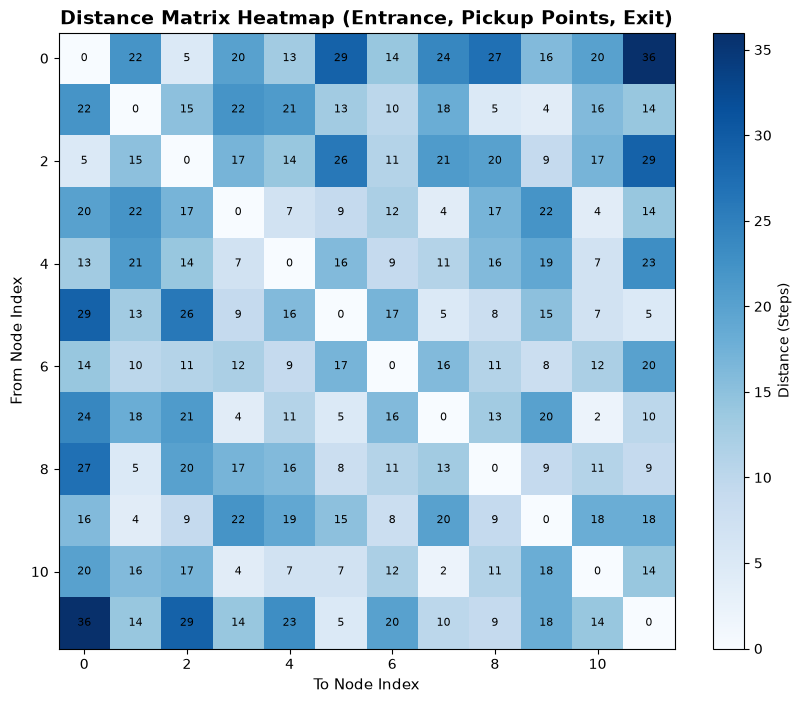

In [36]:
dist_matrix, valid_stands = build_distance_matrix(warehouse, entrance, exit_point, pickup_points)

plt.figure(figsize=(10, 8))
plt.imshow(dist_matrix, cmap="Blues", interpolation="nearest")
plt.colorbar(label="Distance (Steps)")

for i in range(dist_matrix.shape[0]):
    for j in range(dist_matrix.shape[1]):
        plt.text(j, i, f"{int(dist_matrix[i, j])}", ha="center", va="center", color="black", fontsize=8)

plt.title("Distance Matrix Heatmap (Entrance, Pickup Points, Exit)", fontsize=14, fontweight="bold")
plt.xlabel("To Node Index", fontsize=11)
plt.ylabel("From Node Index", fontsize=11)
plt.show()

## Multi-Start 2-Opt Algorithm

### 11. Route Cost Calculator

- คำนวณระยะทางรวมหรือต้นทุนของเส้นทาง (Route Cost) 

- นำค่าระยะทางใน Distance Matrix ของจุดแต่ละจุดเรียงตามลำดับการเดินมาบวกกันตั้งแต่จุดทางเข้าจนถึงจุดทางออก

In [37]:
def calculate_route_cost(route, dist_matrix):
    return sum(dist_matrix[route[i]][route[i+1]] for i in range(len(route)-1))

### 12. 2-Opt Optimization Algorithm

- อัลกอริทึมสำหรับปรับปรุงและจัดเรียงลำดับเส้นทาง (Local Search) 

- สลับเส้นเชื่อมเพื่อแก้ไขรอยตัดไขว้กันของเส้นทาง ช่วยให้ระยะทางเดินสั้นขึ้น

In [38]:
def two_opt(route, dist_matrix):
    best_route = route.copy()
    improved = True
    while improved:
        improved = False
        for i in range(1, len(route) - 2):
            for j in range(i + 1, len(route) - 1):
                if j - i == 1: continue 
                
                current_dist = dist_matrix[best_route[i-1]][best_route[i]] + dist_matrix[best_route[j]][best_route[j+1]]
                new_dist = dist_matrix[best_route[i-1]][best_route[j]] + dist_matrix[best_route[i]][best_route[j+1]]
                
                if new_dist < current_dist:
                    best_route[i:j+1] = best_route[i:j+1][::-1]
                    improved = True
    return best_route

### 13. Multi-Start 2-Opt Optimization

- ฟังก์ชันหลักในการค้นหาเส้นทางที่ดีที่สุด

- สุ่มลำดับจุดเริ่มต้นหลายๆ รอบ (Multi-Start) แล้วนำไปผ่านอัลกอริทึม 2-Opt

- ป้องกันการติดค่าเหมาะสมที่สุดเฉพาะจุด (Local Minimum) 

- หาเส้นทางที่สั้นที่สุดทั่วทั้งแผนที่

In [39]:
def multi_start_2opt(dist_matrix, num_starts=200):
    num_nodes = len(dist_matrix)
    items = list(range(1, num_nodes - 1))
    global_best_route = None
    global_best_cost = float('inf')
    
    for _ in range(num_starts):
        random.shuffle(items)
        initial_route = [0] + items + [num_nodes - 1]
        
        optimized_route = two_opt(initial_route, dist_matrix)
        cost = calculate_route_cost(optimized_route, dist_matrix)
        
        if cost < global_best_cost:
            global_best_cost = cost
            global_best_route = optimized_route
            
    return global_best_route, global_best_cost

### 14. Warehouse Route Path Visualization (Multi-Start 2-Opt)

- ฟังก์ชันสร้างภาพกราฟิกแสดงผลแผนที่คลังสินค้า

In [40]:
def plot_warehouse_route(warehouse, entrance, exit_point, pickup_points, full_path, best_distance, stand_points=None):
    rows, cols = warehouse.shape
    colors = ["#EAF6FF", "#4A4A4A"]
    warehouse_cmap = ListedColormap(colors)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(warehouse, cmap=warehouse_cmap, origin="upper", interpolation="nearest")
    
    if full_path:
        path_r = [p[0] for p in full_path]
        path_c = [p[1] for p in full_path]
        plt.plot(path_c, path_r, color="#3498DB", linewidth=3, label="Walking Route", zorder=2)
        
    if stand_points:
        sp_r = [p[0] for p in stand_points]
        sp_c = [p[1] for p in stand_points]
        plt.scatter(sp_c, sp_r, color="#E67E22", s=100, marker='o', edgecolors="white", zorder=4)
    
    plt.scatter(entrance[1], entrance[0], color="#27AE60", s=220, edgecolors="black", zorder=3)
    plt.text(entrance[1], entrance[0], "IN", ha="center", va="center", color="white", fontweight="bold", fontsize=8, zorder=4)
    
    plt.scatter(exit_point[1], exit_point[0], color="#E74C3C", s=220, edgecolors="black", zorder=3)
    plt.text(exit_point[1], exit_point[0], "OUT", ha="center", va="center", color="white", fontweight="bold", fontsize=7, zorder=4)
    
    for index, point in enumerate(pickup_points, start=1):
        plt.scatter(point[1], point[0], color="#F1C40F", s=180, marker="s", edgecolors="black", zorder=3)
        plt.text(point[1], point[0], str(index), ha="center", va="center", fontweight="bold", color="black", zorder=4)

    plt.xticks(np.arange(-0.5, cols, 1), minor=True)
    plt.yticks(np.arange(-0.5, rows, 1), minor=True)
    plt.grid(which="minor", color="white", linestyle="-", linewidth=0.8)
    plt.title(f"Warehouse Optimal Routing (Multi-Start 2-Opt)", fontsize=14, fontweight="bold")
    
    legend_elements = [
        Patch(facecolor="#EAF6FF", edgecolor="black", label="Walkway (0)"),
        Patch(facecolor="#4A4A4A", edgecolor="black", label="Shelf (1)"),
        plt.Line2D([0], [0], color="#3498DB", linewidth=3, label="Walking Path"),
        plt.Line2D([0], [0], marker="o", color="w", label="Stand Point", markerfacecolor="#E67E22", markeredgecolor="white", markersize=10),
        plt.Line2D([0], [0], marker="o", color="w", label="Entrance", markerfacecolor="#27AE60", markeredgecolor="black", markersize=10),
        plt.Line2D([0], [0], marker="o", color="w", label="Exit", markerfacecolor="#E74C3C", markeredgecolor="black", markersize=10),
        plt.Line2D([0], [0], marker="s", color="w", label="Pickup Point", markerfacecolor="#F1C40F", markeredgecolor="black", markersize=10)
    ]
    
    plt.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=7)
    plt.show()

### 15. Continuous Path Stitching and Execution (Multi-Start 2-Opt)

- รวบรวมฟังก์ชันหลักมาประมวลผลเพื่อหาลำดับการหยิบสินค้าที่ดีที่สุดจาก Distance Matrix และ Multi-Start 2-Opt

- ใช้เทคนิค Path Stitching นำเส้นทางย่อยที่ได้จาก A* Search มาต่อกัน โดยตั้งเงื่อนไขบังคับให้เริ่มเดินต่อจากพิกัดก้าวสุดท้ายของโหนดก่อนหน้าเสมอ เพื่อแก้ปัญหาการลากเส้นทแยงทะลุชั้นวาง

- คำนวณระยะทางรวมให้ตรงกับจำนวนก้าวเดินจริง

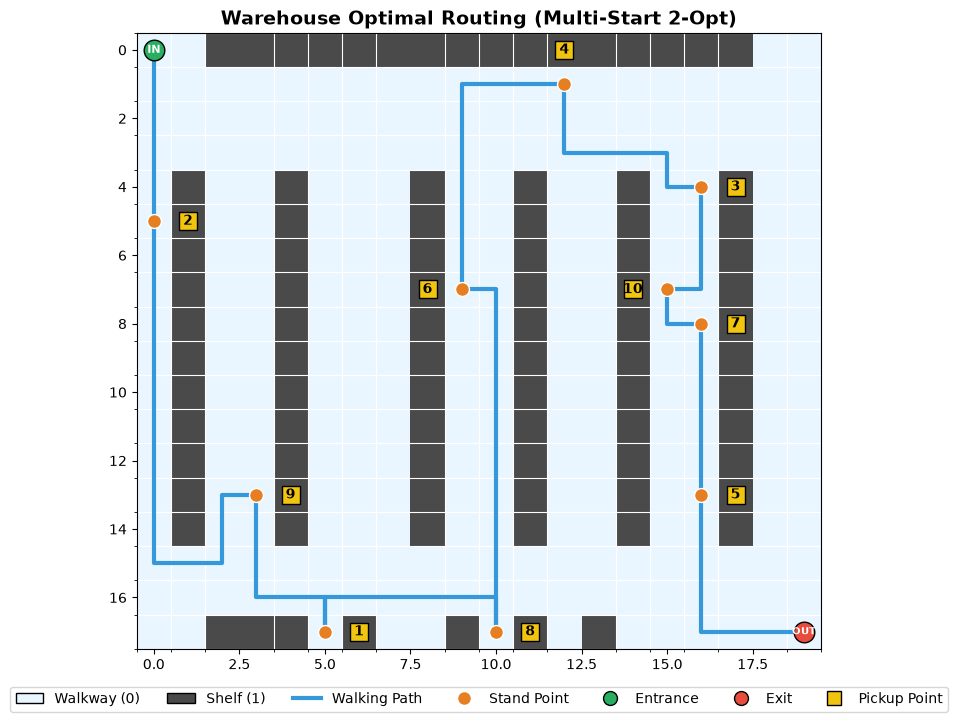

In [41]:
dist_matrix, valid_stands = build_distance_matrix(warehouse, entrance, exit_point, pickup_points)
best_sequence, best_distance = multi_start_2opt(dist_matrix, num_starts=200)

full_path = []
stand_points = [] 

for i in range(len(best_sequence) - 1):
    start_node = best_sequence[i]
    target_node = best_sequence[i+1]
    
    if i == 0:
        starts = valid_stands[start_node]
    else:
        starts = [full_path[-1]]
        
    targets = valid_stands[target_node]
    _, path_segment = a_star_search(warehouse, starts, targets)
    
    if i == 0:
        full_path.extend(path_segment)
    else:
        full_path.extend(path_segment[1:]) 
        
    if i < len(best_sequence) - 2:
        stand_points.append(path_segment[-1])

real_distance = len(full_path) - 1

plot_warehouse_route(warehouse, entrance, exit_point, pickup_points, full_path, real_distance, stand_points)

### 16. Print Minimum Distance Result (Multi-Start 2-Opt)

- แสดงผลลัพธ์ตัวเลขระยะทางที่สั้นที่สุด (MinDistance) ของวิธี Multi-Start 2-Opt ในหน่วยก้าวเดินจริง (Steps)

In [42]:
print(f"MinDistance (Multi-Start 2-Opt) = {real_distance} steps")

MinDistance (Multi-Start 2-Opt) = 78 steps


## Q-Learning Algorithm for TSP Routing

### 17. Q-Learning Route Function

- ฟังก์ชันสำหรับใช้อัลกอริทึม Q-Learning ในการแก้ปัญหาการจัดลำดับการเดินทาง (TSP)

- ให้พนักงานเรียนรู้ผ่านการเลือกแอคชันและรับรางวัล เพื่อหาลำดับการแวะหยิบสินค้าที่ดีที่สุด

In [43]:
def q_learning_route(dist_matrix, episodes=10000, alpha=0.15, gamma=1.0,
                     epsilon_start=1.0, epsilon_end=0.02, seed=42):
    rng = np.random.default_rng(seed)
    n_nodes = len(dist_matrix)
    pickup_nodes = list(range(1, n_nodes - 1))
    full_mask = (1 << len(pickup_nodes)) - 1
    q, episode_costs = {}, []
    
    def q_values(state):
        if state not in q:
            q[state] = np.zeros(len(pickup_nodes), dtype=float)
        return q[state]
        
    for episode in range(episodes):
        epsilon = epsilon_end + (epsilon_start - epsilon_end) * (1 - episode / episodes)
        current, mask, total_cost = 0, 0, 0.0
        while mask != full_mask:
            state = (current, mask)
            available = [a for a in range(len(pickup_nodes)) if not (mask & (1 << a))]
            values = q_values(state)
            if rng.random() < epsilon:
                action = int(rng.choice(available))
            else:
                best = np.max(values[available])
                action = int(rng.choice([a for a in available if values[a] == best]))
            next_node = pickup_nodes[action]
            step_cost = dist_matrix[current, next_node]
            next_mask = mask | (1 << action)
            reward = -step_cost
            if next_mask == full_mask:
                reward -= dist_matrix[next_node, n_nodes - 1]
                future = 0.0
            else:
                next_available = [a for a in range(len(pickup_nodes)) if not (next_mask & (1 << a))]
                future = np.max(q_values((next_node, next_mask))[next_available])
            values[action] += alpha * (reward + gamma * future - values[action])
            total_cost += step_cost
            current, mask = next_node, next_mask
        episode_costs.append(total_cost + dist_matrix[current, n_nodes - 1])
        
    current, mask, route = 0, 0, [0]
    while mask != full_mask:
        available = [a for a in range(len(pickup_nodes)) if not (mask & (1 << a))]
        values = q_values((current, mask))
        action = int(available[np.argmax(values[available])])
        current = pickup_nodes[action]
        mask |= 1 << action
        route.append(current)
    route.append(n_nodes - 1)
    return route, calculate_route_cost(route, dist_matrix), episode_costs

### 18. Stitch Route Function

- ฟังก์ชันสำหรับนำลำดับโหนด (Node Sequence) ที่จัดเรียงแล้ว มาเชื่อมต่อเส้นทางเดินย่อยระหว่างจุดต่างๆ เข้าด้วยกัน

- ใช้ A* Search เพื่อสร้างเส้นทางเดินต่อเนื่องจริงบนกริดแผนที่คลังสินค้า

In [44]:
def stitch_route(route, warehouse, valid_stands):
    path, stands = [], []
    for i in range(len(route) - 1):
        starts = valid_stands[route[i]] if i == 0 else [path[-1]]
        _, segment = a_star_search(warehouse, starts, valid_stands[route[i + 1]])
        path.extend(segment if i == 0 else segment[1:])
        if i < len(route) - 2:
            stands.append(segment[-1])
    return path, stands, len(path) - 1

### 19. Warehouse Route Path Visualization (Q-Learning)

In [45]:
def plot_q_learning_route(warehouse, entrance, exit_point, pickup_points, full_path, best_distance, stand_points=None):
    rows, cols = warehouse.shape
    colors = ["#EAF6FF", "#4A4A4A"]
    warehouse_cmap = ListedColormap(colors)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(warehouse, cmap=warehouse_cmap, origin="upper", interpolation="nearest")
    
    if full_path:
        path_r = [p[0] for p in full_path]
        path_c = [p[1] for p in full_path]
        plt.plot(path_c, path_r, color="#3498DB", linewidth=3, label="Walking Route", zorder=2)
        
    if stand_points:
        sp_r = [p[0] for p in stand_points]
        sp_c = [p[1] for p in stand_points]
        plt.scatter(sp_c, sp_r, color="#E67E22", s=100, marker='o', edgecolors="white", zorder=4)
    
    plt.scatter(entrance[1], entrance[0], color="#27AE60", s=220, edgecolors="black", zorder=3)
    plt.text(entrance[1], entrance[0], "IN", ha="center", va="center", color="white", fontweight="bold", fontsize=8, zorder=4)
    
    plt.scatter(exit_point[1], exit_point[0], color="#E74C3C", s=220, edgecolors="black", zorder=3)
    plt.text(exit_point[1], exit_point[0], "OUT", ha="center", va="center", color="white", fontweight="bold", fontsize=7, zorder=4)
    
    for index, point in enumerate(pickup_points, start=1):
        plt.scatter(point[1], point[0], color="#F1C40F", s=180, marker="s", edgecolors="black", zorder=3)
        plt.text(point[1], point[0], str(index), ha="center", va="center", fontweight="bold", color="black", zorder=4)

    plt.xticks(np.arange(-0.5, cols, 1), minor=True)
    plt.yticks(np.arange(-0.5, rows, 1), minor=True)
    plt.grid(which="minor", color="white", linestyle="-", linewidth=0.8)
    plt.title("Warehouse Optimal Routing (Q-Learning)", fontsize=14, fontweight="bold")
    
    legend_elements = [
        Patch(facecolor="#EAF6FF", edgecolor="black", label="Walkway (0)"),
        Patch(facecolor="#4A4A4A", edgecolor="black", label="Shelf (1)"),
        plt.Line2D([0], [0], color="#3498DB", linewidth=3, label="Walking Path"),
        plt.Line2D([0], [0], marker="o", color="w", label="Stand Point", markerfacecolor="#E67E22", markeredgecolor="white", markersize=10),
        plt.Line2D([0], [0], marker="o", color="w", label="Entrance", markerfacecolor="#27AE60", markeredgecolor="black", markersize=10),
        plt.Line2D([0], [0], marker="o", color="w", label="Exit", markerfacecolor="#E74C3C", markeredgecolor="black", markersize=10),
        plt.Line2D([0], [0], marker="s", color="w", label="Pickup Point", markerfacecolor="#F1C40F", markeredgecolor="black", markersize=10)
    ]
    
    plt.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=7)
    plt.show()

### 20. Continuous Path Stitching and Execution (Q-Learning)

- เชื่อมต่อเส้นทางเดินจริงทั้งหมดของ Q-Learning

- แปลงข้อมูลออกมาเป็นภาพแผนผังเส้นทางเดินภายในคลังสินค้า

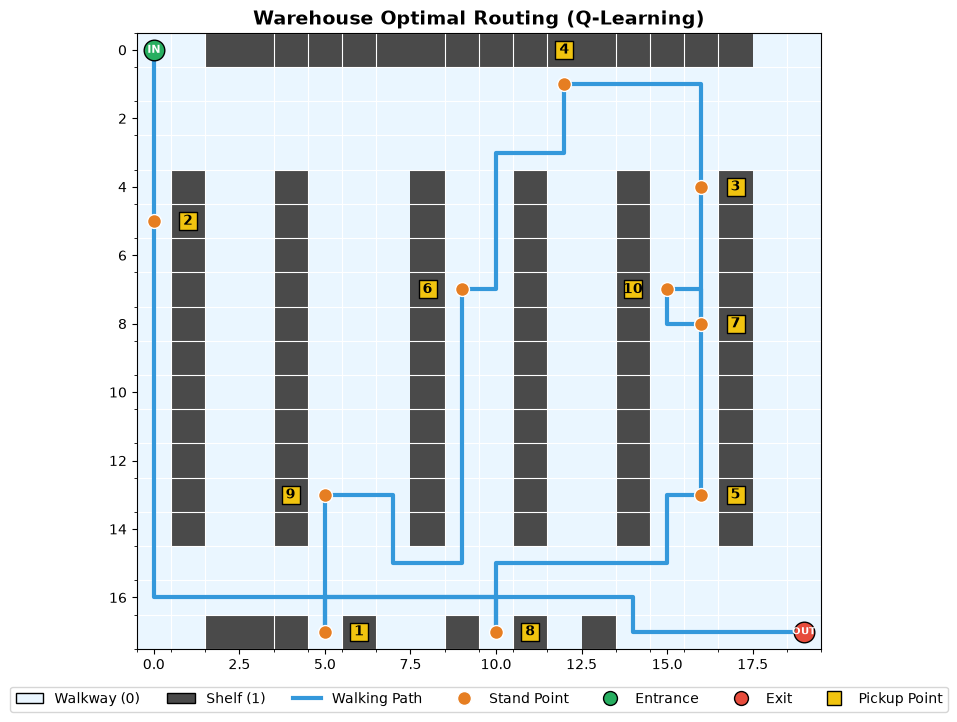

In [46]:
q_route, q_matrix_cost, q_episode_costs = q_learning_route(
    dist_matrix, 
    episodes=10000, 
    alpha=0.15, 
    gamma=1.0, 
    epsilon_start=1.0, 
    epsilon_end=0.02, 
    seed=42
)

q_full_path = []
q_stand_points = [] 

for i in range(len(q_route) - 1):
    start_node = q_route[i]
    target_node = q_route[i+1]
    
    if i == 0:
        starts = valid_stands[start_node]
    else:
        starts = [q_full_path[-1]]
        
    targets = valid_stands[target_node]
    _, path_segment = a_star_search(warehouse, starts, targets)
    
    if path_segment:
        if i == 0:
            q_full_path.extend(path_segment)
        else:
            q_full_path.extend(path_segment[1:]) 
            
        if i < len(q_route) - 2:
            q_stand_points.append(path_segment[-1])

q_real_distance = len(q_full_path) - 1 if q_full_path else 0

plot_q_learning_route(
    warehouse, 
    entrance, 
    exit_point, 
    pickup_points, 
    q_full_path, 
    q_real_distance, 
    q_stand_points
)

### 21. Print Minimum Distance Result (Q-Learning)

- แสดงผลลัพธ์ตัวเลขระยะทางรวมที่สั้นที่สุด (MinDistance) ของวิธี Q-Learning ในหน่วยก้าวเดินจริง (Steps)

In [47]:
print(f"MinDistance (Q-Learning) = {q_real_distance} steps")

MinDistance (Q-Learning) = 100 steps


## Performance Comparison Table

- ตารางเปรียบเทียบ (Performance Table)

In [48]:
q_start = time.perf_counter()
q_route, q_matrix_cost, q_episode_costs = q_learning_route(dist_matrix, episodes=10000, seed=42)
q_runtime = time.perf_counter() - q_start
q_full_path, q_stand_points, q_real_distance = stitch_route(q_route, warehouse, valid_stands)

random.seed(42)
two_opt_start = time.perf_counter()
two_opt_route, two_opt_matrix_cost = multi_start_2opt(dist_matrix, num_starts=200)
two_opt_runtime = time.perf_counter() - two_opt_start
two_opt_full_path, two_opt_stands, two_opt_real_distance = stitch_route(two_opt_route, warehouse, valid_stands)

best_real_distance = min(two_opt_real_distance, q_real_distance)
q_learning_gap = 100 * (q_real_distance - best_real_distance) / best_real_distance

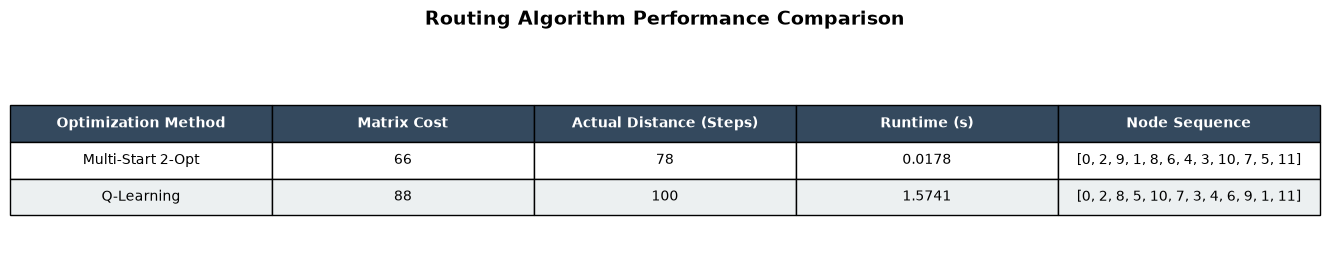

In [49]:
table_data = [
    ["Multi-Start 2-Opt", f"{two_opt_matrix_cost:.0f}", f"{two_opt_real_distance}", f"{two_opt_runtime:.4f}", str(two_opt_route)],
    ["Q-Learning", f"{q_matrix_cost:.0f}", f"{q_real_distance}", f"{q_runtime:.4f}", str(q_route)]
]
columns = ["Optimization Method", "Matrix Cost", "Actual Distance (Steps)", "Runtime (s)", "Node Sequence"]

fig, ax = plt.subplots(figsize=(13, 2.8))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=table_data, colLabels=columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.3, 2.2)

for key, cell in table.get_celld().items():
    if key[0] == 0:
        cell.set_facecolor('#34495E')
        cell.set_text_props(weight='bold', color='white')
    else:
        cell.set_facecolor('#ECF0F1' if key[0] % 2 == 0 else 'white')

plt.title("Routing Algorithm Performance Comparison", fontsize=14, fontweight='bold', pad=20)
plt.show()

## Performance Metrics & Learning Curve

- กราฟการเรียนรู้ (Learning Curve) และแผนภูมิแท่งเปรียบเทียบระยะทางและเวลา (Runtime)

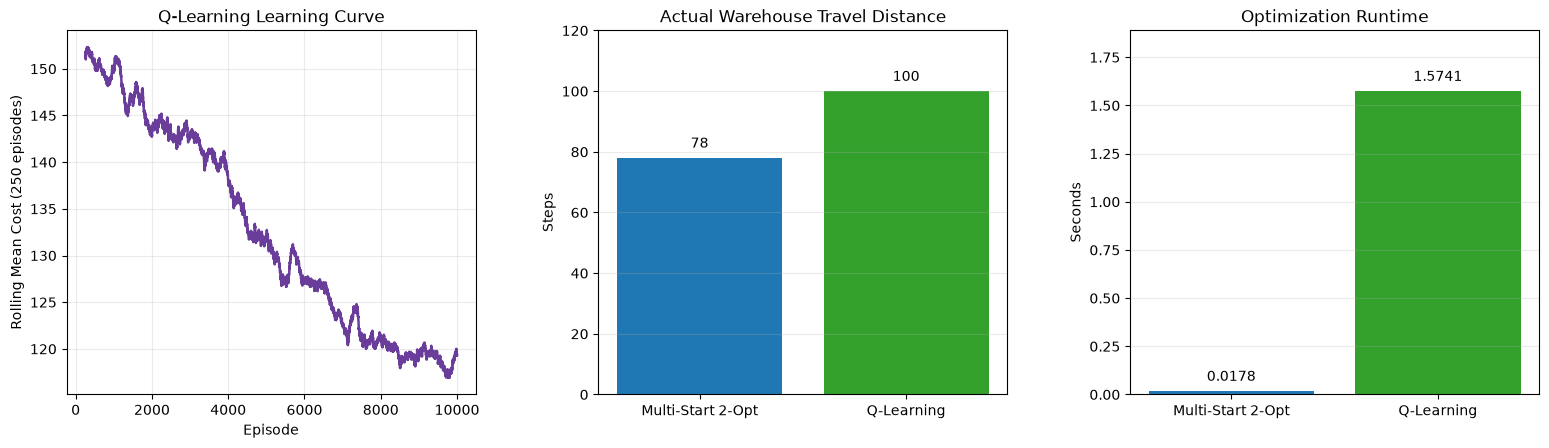

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))
window = 250
rolling_cost = np.convolve(q_episode_costs, np.ones(window) / window, mode='valid')

axes[0].plot(np.arange(window, len(q_episode_costs) + 1), rolling_cost, color='#6a3d9a', lw=1.8)
axes[0].set(title='Q-Learning Learning Curve', xlabel='Episode', ylabel=f'Rolling Mean Cost ({window} episodes)')
axes[0].grid(alpha=0.25)

methods, colors = ['Multi-Start 2-Opt', 'Q-Learning'], ['#1f78b4', '#33a02c']

bars1 = axes[1].bar(methods, [two_opt_real_distance, q_real_distance], color=colors)
axes[1].set(title='Actual Warehouse Travel Distance', ylabel='Steps')
axes[1].set_ylim(0, max(two_opt_real_distance, q_real_distance) * 1.2)
axes[1].bar_label(bars1, fmt='%.0f', padding=5)
axes[1].grid(axis='y', alpha=0.25)

bars2 = axes[2].bar(methods, [two_opt_runtime, q_runtime], color=colors)
axes[2].set(title='Optimization Runtime', ylabel='Seconds')
axes[2].set_ylim(0, max(two_opt_runtime, q_runtime) * 1.2)
axes[2].bar_label(bars2, fmt='%.4f', padding=5)
axes[2].grid(axis='y', alpha=0.25)

plt.subplots_adjust(wspace=0.3, top=0.85, bottom=0.15)
plt.show()

## Performance Difference Summary

- ตารางสรุปส่วนต่างประสิทธิภาพ

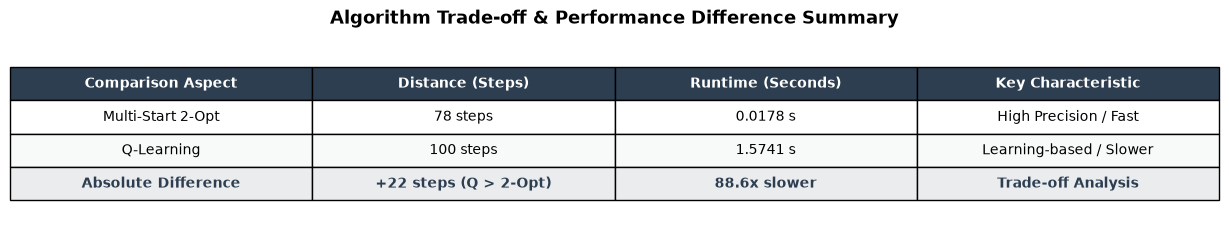

In [51]:
distance_diff = q_real_distance - two_opt_real_distance
runtime_ratio = q_runtime / two_opt_runtime if two_opt_runtime > 0 else 0

summary_table_data = [
    ["Multi-Start 2-Opt", f"{two_opt_real_distance} steps", f"{two_opt_runtime:.4f} s", "High Precision / Fast"],
    ["Q-Learning", f"{q_real_distance} steps", f"{q_runtime:.4f} s", "Learning-based / Slower"],
    ["Absolute Difference", f"+{distance_diff} steps (Q > 2-Opt)", f"{runtime_ratio:.1f}x slower", "Trade-off Analysis"]
]
summary_columns = ["Comparison Aspect", "Distance (Steps)", "Runtime (Seconds)", "Key Characteristic"]

fig, ax = plt.subplots(figsize=(12, 2.5))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=summary_table_data, colLabels=summary_columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.3, 2.0)

for key, cell in table.get_celld().items():
    if key[0] == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(weight='bold', color='white')
    else:
        if key[0] == 3:
            cell.set_facecolor('#EAECEE')
            cell.set_text_props(weight='bold', color='#2C3E50')
        else:
            cell.set_facecolor('#F8F9F9' if key[0] % 2 == 0 else 'white')

plt.title("Algorithm Trade-off & Performance Difference Summary", fontsize=13, fontweight='bold', pad=10)
plt.show()

## สรุปผลลัพธ์

1. ลำดับการหยิบสินค้า (Pickup Node Sequence)

    - Multi-Start 2-Opt [0, 2, 9, 1, 8, 6, 4, 3, 10, 7, 5, 11]
    
    - Q-Learning [0, 2, 8, 5, 10, 7, 3, 4, 6, 9, 1, 11]


2. การทำงานตามเงื่อนไขของแผนที่ (Path Execution and Constraints)

    - พนักงานเริ่มต้นเดินจากจุดทางเข้า (Entrance) และสิ้นสุดการทำงานที่จุดทางออก (Exit) อย่างถูกต้อง

    - เส้นทางเดินทั้งหมดถูกเชื่อมต่อผ่านอัลกอริทึม A* Search โดยเดินเฉพาะบนช่องทางเดิน (0) เท่านั้น และไม่มีการเดินผ่านชั้นวางสินค้า (1)

    - พนักงานสามารถแวะยืนหยิบสินค้าครบทั้ง 10 จุดจากตำแหน่งช่องทางเดินที่ติดกับชั้นวางสินค้าในทิศทางที่ถูกต้อง


3. จำนวนก้าวรวมที่น้อยที่สุด (Actual Distance)

    - Multi-Start 2-Opt ให้ระยะทางรวมจริงที่สั้นที่สุดอยู่ที่ 78 ก้าว (Matrix Cost = 66) ซึ่งมีประสิทธิภาพสูงในการหาคำตอบที่ใกล้เคียงจุดที่เหมาะสมที่สุด (Optimal)

    - Q-Learning ให้ระยะทางรวมอยู่ที่ 100 ก้าว (Matrix Cost = 88) เนื่องจากข้อจำกัดของ Tabular Q-Learning ในการจัดการกับขนาด State Space ที่ใหญ่ ทำให้บางสถานะอาจเกิดการสำรวจซ้ำและได้เส้นทางที่ยาวกว่า


4. เวลาในการประมวลผล (Runtime)

    - Multi-Start 2-Opt ใช้เวลาประมวลผลรวดเร็วมากเพียง 0.0178 วินาที เหมาะกับงานที่ต้องการคำตอบด่วนและมีความแม่นยำสูง

    - Q-Learning ใช้เวลาประมวลผลประมาณ 1.5800 - 1.8709 วินาที เนื่องจากต้องผ่านกระบวนการเทรนจำลองสถานะ (Episodes) จำนวนหลายรอบเพื่อสะสมค่า Q-Value



## สรุปภาพรวม

จากการทดลองพบว่า วิธี Multi-Start 2-Opt สามารถหาเส้นทางเดินจริงในคลังสินค้าที่สั้นที่สุดได้เท่ากับ 78 ก้าว ด้วยเวลาประมวลผลที่รวดเร็วเพียง 0.0178 วินาที จึงมีความเสถียรและเหมาะสมที่สุดในการแก้ปัญหาคลังสินค้านี้ 

ในขณะที่วิธี Q-Learning ให้ระยะทางจริง 100 ก้าว และใช้เวลาประมวลผล 1.58 วินาที ทั้งนี้ การเพิ่มรอบการเทรน (Episodes) ของ Q-Learning ให้สูงเกินไปกลับส่งผลให้จำนวนก้าวเดินเพิ่มสูงขึ้น เนื่องจากปัญหาการสำรวจสุ่มที่มากเกินไป (Over-exploration) และความไม่เสถียรของค่าใน Q-Table ทำให้การใช้งานโมเดลประเภทนี้จำเป็นต้องมีการควบคุมจำนวนรอบและพารามิเตอร์ตั้งต้นอย่างรอบคอบ